# Experiment: Single Layered Perceptron

## Objective

The objective of this experiment is to understand the concept of an artificial neuron and implement a **Single Layer Perceptron** from scratch for binary classification. Students will:

- Understand the architecture of a single-layer perceptron.
- Learn the Perceptron Learning Algorithm.
- Understand the role of activation functions.
- Visualize the learning process.
- Evaluate the classifier using a real-world binary classification dataset.

---

# Dataset Description

| Attribute | Details |
|-----------|----------|
| **Dataset Name** | Banknote Authentication Dataset |
| **Source** | UCI Machine Learning Repository |
| **Dataset Link** | https://archive.ics.uci.edu/dataset/267/banknote+authentication |
| **Number of Instances** | 1372 |
| **Number of Features** | 4 Numerical Features |
| **Classes** | 2 (Authentic and Forged Banknotes) |
| **Missing Values** | None |
| **Task** | Binary Classification |

---

## Dataset Features

The dataset consists of the following numerical features extracted from banknote images:

1. Variance of Wavelet Transformed Image
2. Skewness of Wavelet Transformed Image
3. Curtosis of Wavelet Transformed Image
4. Entropy of Image

**Target Variable**

- **0** → Authentic Banknote
- **1** → Forged Banknote

---

## Theory

A **Single Layer Perceptron (SLP)** is one of the simplest forms of an Artificial Neural Network introduced by **Frank Rosenblatt (1958)**. It consists of a single neuron that receives multiple input features and produces a binary output.

The perceptron computes a weighted sum of the inputs and passes it through a threshold activation function.

### Mathematical Model

Weighted Sum:

\[
z = \sum_{i=1}^{n} w_i x_i + b
\]

where:

- \(x_i\) = Input feature
- \(w_i\) = Weight
- \(b\) = Bias

Activation Function:

\[
y =
\begin{cases}
1, & z \ge 0 \\
0, & z < 0
\end{cases}
\]

---

## Perceptron Learning Rule

Weights are updated using the following equation:

\[
w = w + \eta (t-y)x
\]

Bias is updated as:

\[
b = b + \eta (t-y)
\]

where:

- \(\eta\) = Learning Rate
- \(t\) = Actual Target
- \(y\) = Predicted Output

The learning process continues until all samples are correctly classified or the maximum number of epochs is reached.

---

## Algorithm

1. Load the dataset.
2. Separate features and target labels.
3. Normalize the feature values (recommended).
4. Initialize weights and bias to zero or small random values.
5. For each training sample:
   - Compute the weighted sum.
   - Apply the step activation function.
   - Calculate the prediction error.
   - Update weights and bias.
6. Repeat for multiple epochs until convergence.
7. Test the trained model.
8. Calculate classification accuracy.

---

## Expected Output

- Successfully train a Single Layer Perceptron.
- Classify banknotes as authentic or forged.
- Display learned weights and bias.
- Calculate prediction accuracy.
- Plot training accuracy or error across epochs.

---

# Result

The Single Layer Perceptron was successfully implemented and trained using the Banknote Authentication Dataset. The model learned the optimal weights and bias through the perceptron learning algorithm and performed binary classification of banknotes into authentic and forged categories. The experiment demonstrated the working principle of an artificial neuron and the effectiveness of the perceptron for linearly separable classification problems.

In [1]:
# ==============================
# Experiment 1 - Task 1
# Dataset Exploration
# ==============================

import pandas as pd

columns = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]

df = pd.read_csv(
    "/kaggle/input/datasets/kalpanabhaskar/banknote-authentication/data_banknote_authentication.txt", 
    header=None,
    names=columns
)

# 1. Display first five samples
print("="*60)
print("First Five Samples")
print("="*60)
print(df.head())

# 2. Dataset dimensions
print("\n" + "="*60)
print("Dataset Dimensions")
print("="*60)
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

# 3. Dataset Information
print("\n" + "="*60)
print("Dataset Information")
print("="*60)
df.info()

# 4. Missing Values
print("\n" + "="*60)
print("Missing Values")
print("="*60)
print(df.isnull().sum())

# 5. Descriptive Statistics
print("\n" + "="*60)
print("Descriptive Statistics")
print("="*60)
print(df.describe())

# 6. Class Distribution
print("\n" + "="*60)
print("Class Distribution")
print("="*60)
print(df["Class"].value_counts())

# 7. Data Types
print("\n" + "="*60)
print("Data Types")
print("="*60)
print(df.dtypes)

First Five Samples
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset Dimensions
Number of Rows    : 1372
Number of Columns : 5

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB

Missing Values
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

Descriptive Statistics
          Variance     Skewness     Curtosis      En

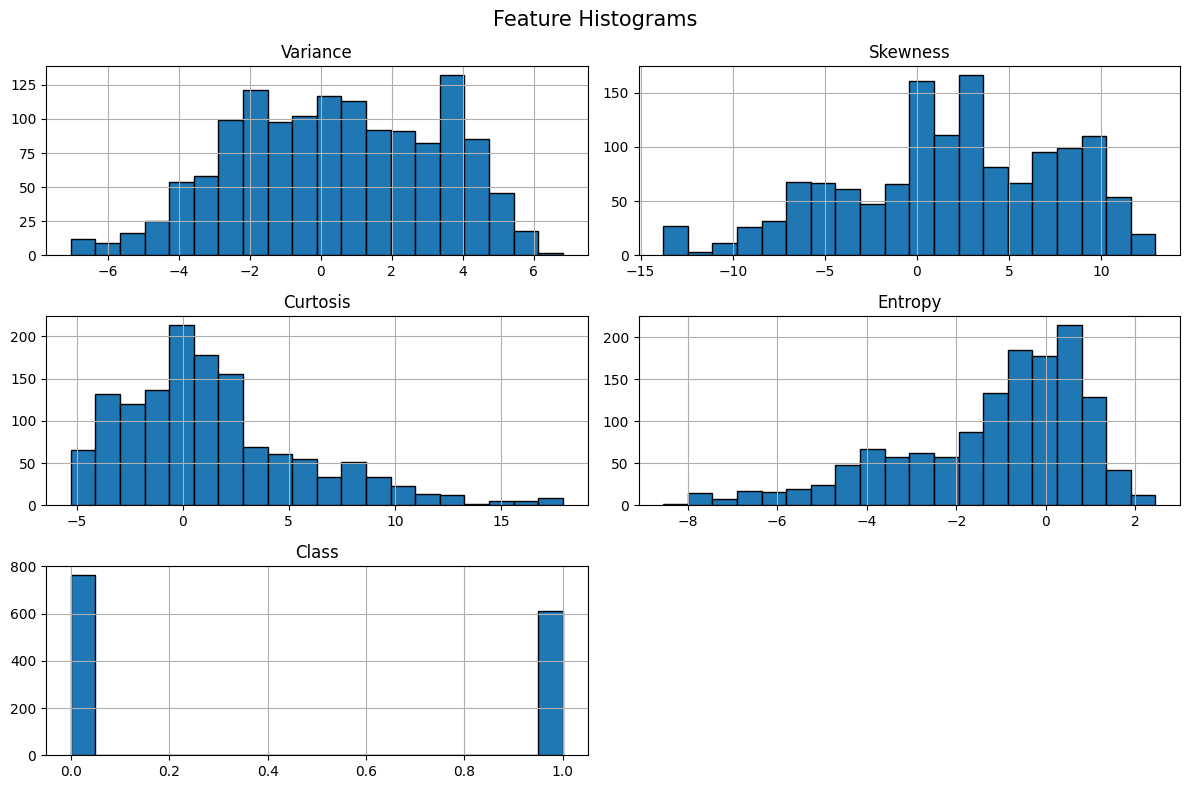

In [3]:
# ==============================
# Task 2 - Histograms
# ==============================

import matplotlib.pyplot as plt

df.hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle("Feature Histograms", fontsize=15)
plt.tight_layout()
plt.show()

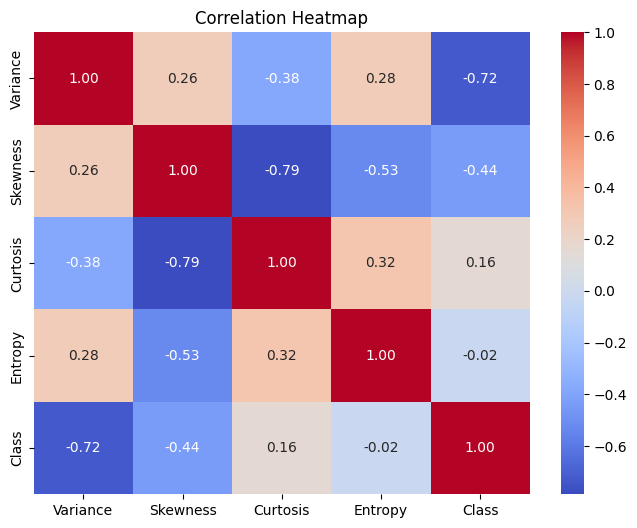

In [4]:
# ==============================
# Task 2 - Correlation Heatmap
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

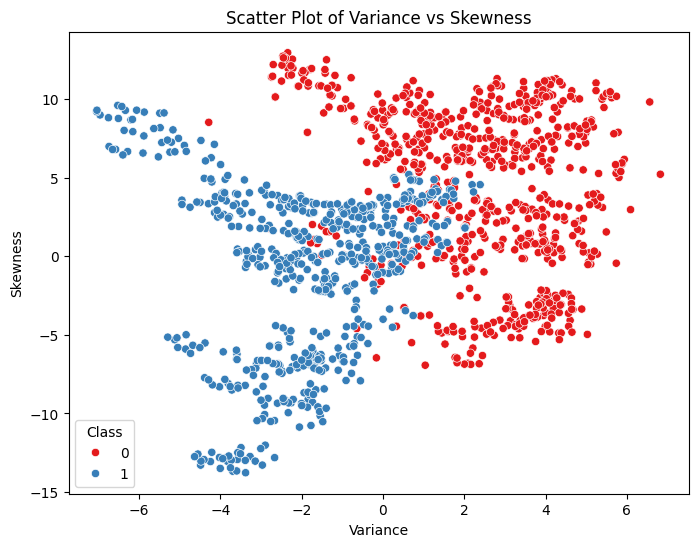

In [5]:
# ==============================
# Task 2 - Scatter Plot
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class",
    palette="Set1"
)

plt.title("Scatter Plot of Variance vs Skewness")
plt.show()

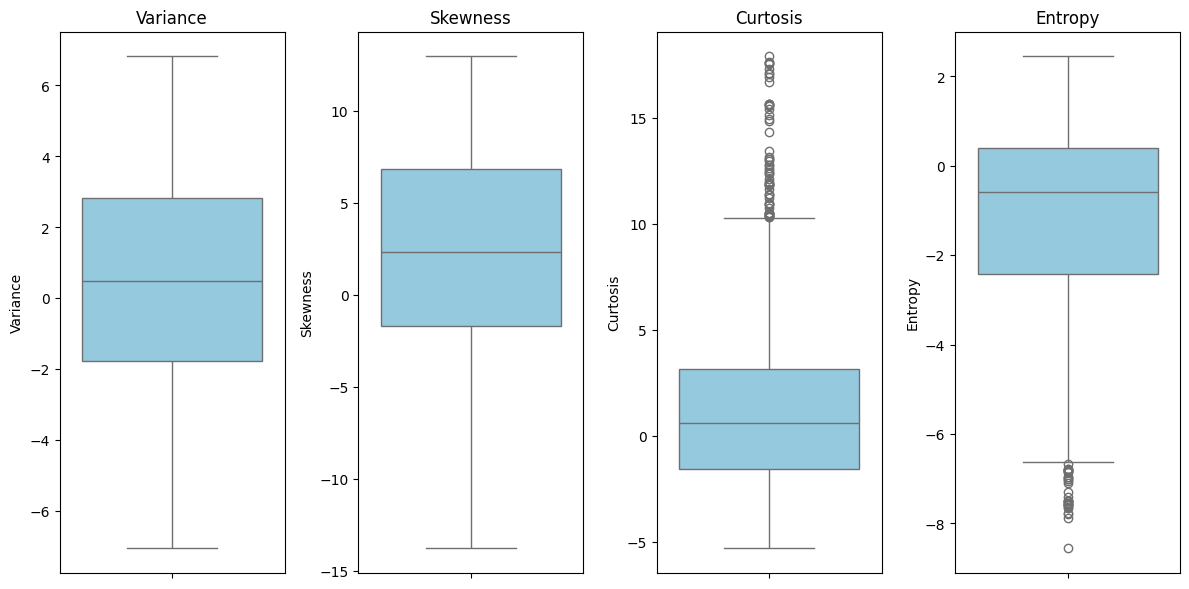

In [6]:
# ==============================
# Task 2 - Boxplots
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[column], color="skyblue")
    plt.title(column)

plt.tight_layout()
plt.show()

In [7]:
# ==============================
# Task 3 - Feature Normalization
# ==============================

from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X   # can help neural network weights converge muhc faster on training

# Convert back to DataFrame (optional)
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("First Five Rows of Normalized Features:")
print(X_scaled.head())

First Five Rows of Normalized Features:
   Variance  Skewness  Curtosis   Entropy
0  1.121806  1.149455 -0.975970  0.354561
1  1.447066  1.064453 -0.895036 -0.128767
2  1.207810 -0.777352  0.122218  0.618073
3  1.063742  1.295478 -1.255397 -1.144029
4 -0.036772 -1.087038  0.736730  0.096587


In [8]:
# ==============================
# Task 3 - Train-Test Split
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)
print("\nTraining Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Set Shape : (1097, 4)
Testing Set Shape  : (275, 4)

Training Labels : (1097,)
Testing Labels  : (275,)


In [9]:
# ==============================
# Task 4 - Perceptron Implementation From Scratch
# ==============================

import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate

        # Weight Initialization
        self.weights = None

        # Bias Initialization
        self.bias = 0

    # Step Activation Function
    def activation(self, z):
        return 1 if z >= 0 else 0

    # Forward Propagation
    def predict(self, X):
        X = np.array(X)

        if X.ndim == 1:
            z = np.dot(X, self.weights) + self.bias
            return self.activation(z)

        predictions = []
        for x in X:
            z = np.dot(x, self.weights) + self.bias
            predictions.append(self.activation(z))

        return np.array(predictions)

    # Perceptron Learning Rule
    def fit(self, X, y, epochs=10):

        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape

        # Initialize weights to zero
        self.weights = np.zeros(n_features)
        self.bias = 0

        self.errors = []

        for epoch in range(epochs):

            errors = 0

            for xi, target in zip(X, y):

                prediction = self.predict(xi)

                update = self.learning_rate * (target - prediction)

                # Weight Update Rule
                self.weights += update * xi

                # Bias Update Rule
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

        return self

In [15]:
# ==============================
# Task 5 - Model Training
# ==============================

import numpy as np

# Lists to store training history
error_history = []
weight_history = []
bias_history = []

# Create perceptron object
perceptron = Perceptron(learning_rate=0.1)

# Training data
X = np.array(X_train)
y = np.array(y_train)

n_samples, n_features = X.shape

# Initialize weights and bias
perceptron.weights = np.zeros(n_features)
perceptron.bias = 0

# Variables to store the best model
best_weights = None
best_bias = None
best_epoch = 0
least_errors = float('inf')

print("=" * 90)
print("Training Perceptron")
print("=" * 90)

for epoch in range(1, 11):

    errors = 0

    for xi, target in zip(X, y):

        prediction = perceptron.predict(xi)

        update = perceptron.learning_rate * (target - prediction)

        # Update weights
        perceptron.weights += update * xi

        # Update bias
        perceptron.bias += update

        if update != 0:
            errors += 1

    error_history.append(errors)
    weight_history.append(perceptron.weights.copy())
    bias_history.append(perceptron.bias)

    # Store best model parameters
    if errors < least_errors:
        least_errors = errors
        best_epoch = epoch
        best_weights = perceptron.weights.copy()
        best_bias = perceptron.bias

    print(f"\nEpoch {epoch}")
    print(f"Misclassified Samples : {errors}")
    print(f"Updated Weights       : {np.round(perceptron.weights, 4)}")
    print(f"Updated Bias          : {round(perceptron.bias, 4)}")

print("\n" + "=" * 90)
print("Best Model Summary")
print("=" * 90)
print(f"Best Epoch            : {best_epoch}")
print(f"Least Misclassifications : {least_errors}")
print(f"Best Weights          : {np.round(best_weights, 4)}")
print(f"Best Bias             : {round(best_bias, 4)}")

Training Perceptron

Epoch 1
Misclassified Samples : 59
Updated Weights       : [-0.6803 -0.9381 -0.6782 -0.1104]
Updated Bias          : -0.3

Epoch 2
Misclassified Samples : 25
Updated Weights       : [-0.7754 -1.0421 -0.8107  0.0345]
Updated Bias          : -0.4

Epoch 3
Misclassified Samples : 20
Updated Weights       : [-0.8021 -1.1266 -0.9166 -0.0362]
Updated Bias          : -0.4

Epoch 4
Misclassified Samples : 19
Updated Weights       : [-0.8828 -1.1959 -1.0008  0.0891]
Updated Bias          : -0.5

Epoch 5
Misclassified Samples : 20
Updated Weights       : [-0.9909 -1.2951 -1.0372  0.1023]
Updated Bias          : -0.5

Epoch 6
Misclassified Samples : 17
Updated Weights       : [-1.0268 -1.2769 -1.1338 -0.0096]
Updated Bias          : -0.6

Epoch 7
Misclassified Samples : 24
Updated Weights       : [-1.0813 -1.3928 -1.1084 -0.0939]
Updated Bias          : -0.6

Epoch 8
Misclassified Samples : 22
Updated Weights       : [-1.1702 -1.3568 -1.3188 -0.0249]
Updated Bias          : -

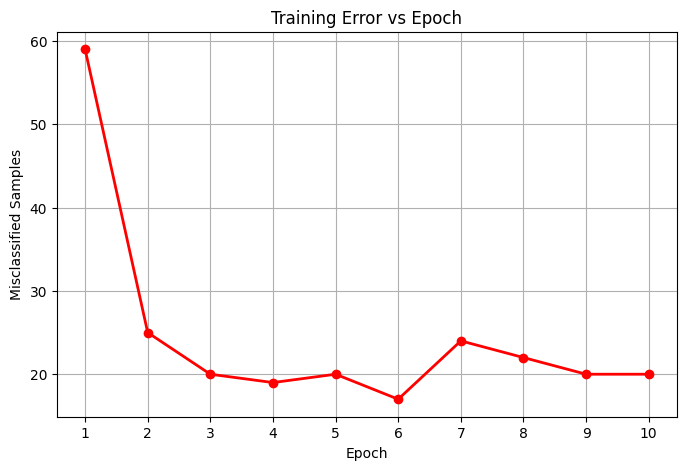

In [17]:
# ==============================
# Training Error vs Epoch
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(error_history)+1),
         error_history,
         marker='o',
         linewidth=2,
         color='red')

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.xticks(range(1, len(error_history)+1))
plt.grid(True)
plt.show()

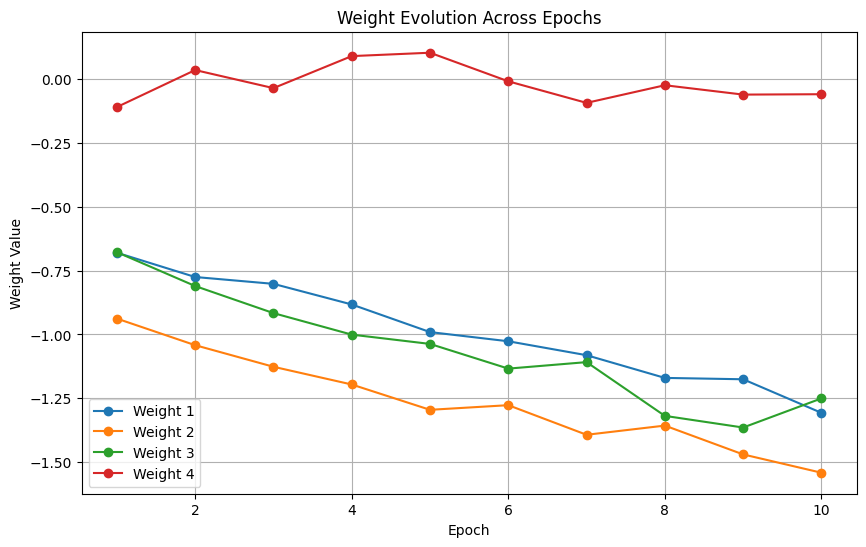

In [18]:
# ==============================
# Weight Evolution
# ==============================

import matplotlib.pyplot as plt
import numpy as np

weights = np.array(weight_history)

plt.figure(figsize=(10,6))

for i in range(weights.shape[1]):
    plt.plot(range(1, len(weights)+1),
             weights[:, i],
             marker='o',
             label=f'Weight {i+1}')

plt.title("Weight Evolution Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.show()

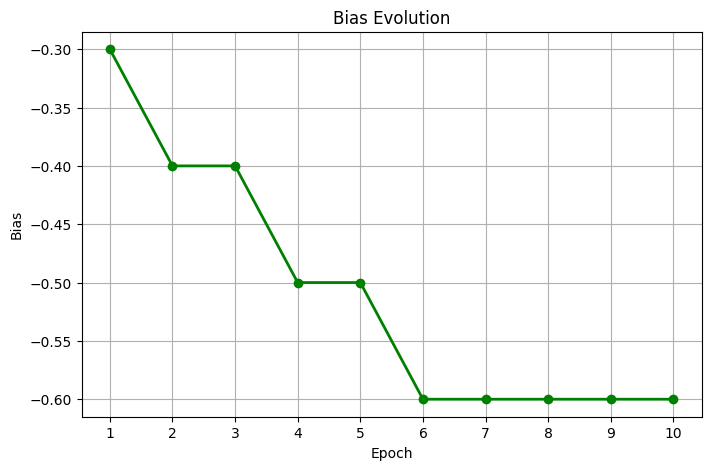

In [19]:
# ==============================
# Bias Evolution
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(bias_history)+1),
         bias_history,
         marker='o',
         linewidth=2,
         color='green')

plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.xticks(range(1, len(bias_history)+1))
plt.grid(True)
plt.show()

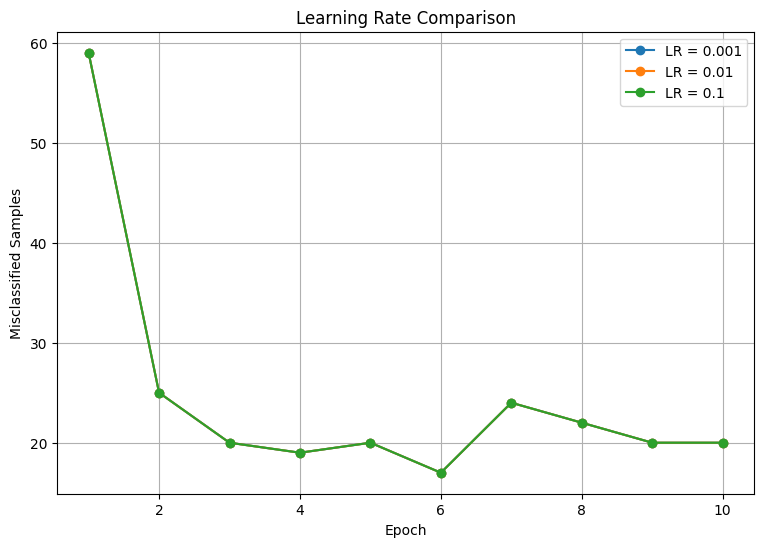

In [20]:
# ==============================
# Learning Rate Comparison
# ==============================

import numpy as np
import matplotlib.pyplot as plt

learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(9,6))

for lr in learning_rates:

    model = Perceptron(learning_rate=lr)

    model.weights = np.zeros(X_train.shape[1])
    model.bias = 0

    errors_list = []

    for epoch in range(10):

        errors = 0

        for xi, target in zip(np.array(X_train), np.array(y_train)):

            prediction = model.predict(xi)

            update = lr * (target - prediction)

            model.weights += update * xi
            model.bias += update

            if update != 0:
                errors += 1

        errors_list.append(errors)

    plt.plot(range(1,11),
             errors_list,
             marker='o',
             label=f'LR = {lr}')

plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.legend()
plt.grid(True)
plt.show()

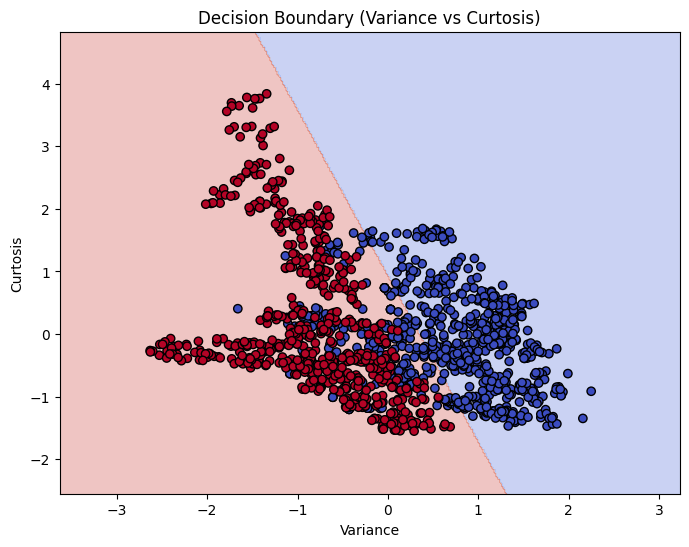

In [28]:
# ==============================
# Decision Boundary
# ==============================

import numpy as np
import matplotlib.pyplot as plt

# Use first two normalized features
X_vis = X_scaled.iloc[:, [0,2]].to_numpy()
y_vis = df["Class"].to_numpy()

# Train a perceptron on only these two features
model = Perceptron(learning_rate=0.1)
model.fit(X_vis, y_vis, epochs=10)

# Mesh grid
x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

plt.scatter(X_vis[:,0],
            X_vis[:,1],
            c=y_vis,
            cmap='coolwarm',
            edgecolors='k')

plt.xlabel("Variance")
plt.ylabel("Curtosis")
plt.title("Decision Boundary (Variance vs Curtosis)")
plt.show()

Model Evaluation (Using Epoch 6)
----------------------------------------
Accuracy : 0.9964
Precision: 0.9919
Recall   : 1.0000
F1-score : 0.9959


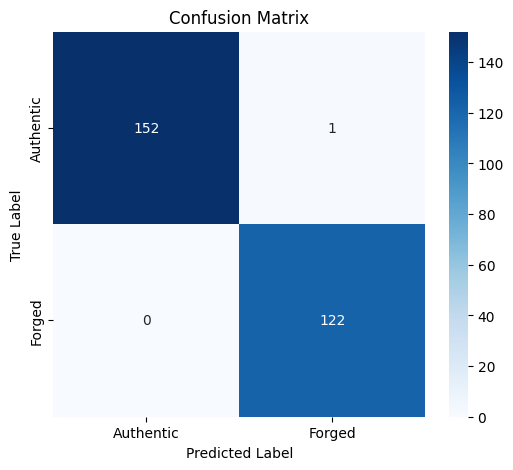

In [16]:
# ==============================
# Task 6 - Model Evaluation
# ==============================

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Restore the 6th epoch parameters
perceptron.weights = best_weights
perceptron.bias = best_bias

# Predict on the test set
y_pred = perceptron.predict(X_test)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation (Using Epoch 6)")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["Authentic", "Forged"],
            yticklabels=["Authentic", "Forged"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()